In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [46]:
d={
    "Name":['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T'],
    "Marks":[45,50,52,48,55,60,58,62,65,59,61,57,63,56,54,51,49,95,100,5]
}
df=pd.DataFrame(d)
print(df)

   Name  Marks
0     A     45
1     B     50
2     C     52
3     D     48
4     E     55
5     F     60
6     G     58
7     H     62
8     I     65
9     J     59
10    K     61
11    L     57
12    M     63
13    N     56
14    O     54
15    P     51
16    Q     49
17    R     95
18    S    100
19    T      5


Visualizing the data


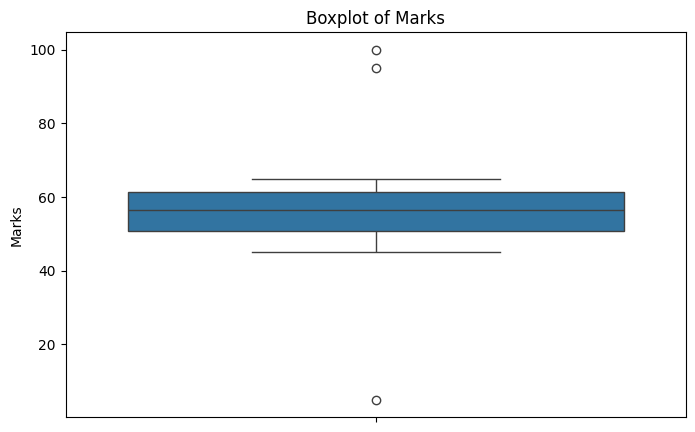

In [47]:
print("Visualizing the data")
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Marks'])
plt.title("Boxplot of Marks")
plt.ylabel("Marks")
plt.show()

In [48]:
print("Detect the outliers using IQR")
Q1=df['Marks'].quantile(0.25)
Q3=df['Marks'].quantile(0.75)
print("Q1=",Q1)
print("Q3=",Q3)



Detect the outliers using IQR
Q1= 50.75
Q3= 61.25


In [49]:
print("Calculte IQR")
IQR=Q3-Q1
print("\nIQR=",IQR)
print("Calculating lower and upper limit")
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Lower bound=",lower_bound)
print("Upper bound=",upper_bound)

Calculte IQR

IQR= 10.5
Calculating lower and upper limit
Lower bound= 35.0
Upper bound= 77.0


In [51]:
print("Identify the outliers")
outliers=df[(df['Marks']<lower_bound) | (df['Marks']>upper_bound)]
print("Outliers detected using IQR")
print(outliers)

Identify the outliers
Outliers detected using IQR
   Name  Marks
17    R     95
18    S    100
19    T      5


Visualizing the outliers


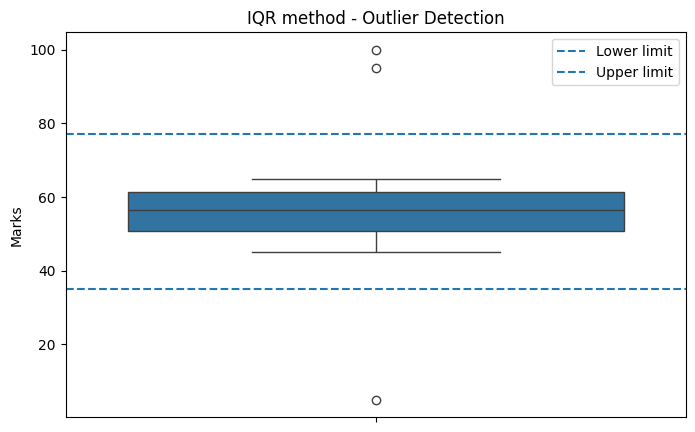

In [52]:
print("Visualizing the outliers")
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Marks'])
plt.axhline(lower_bound,linestyle='--',label='Lower limit')
plt.axhline(upper_bound,linestyle='--',label='Upper limit')

plt.title("IQR method - Outlier Detection")
plt.legend()
plt.show()

In [57]:
print("IQR outlier Treatment - Capping")
df['Marks_IQR_Capped']=df["Marks"].clip(lower=lower_bound,upper=upper_bound)
print(df[["Marks",'Marks_IQR_Capped']])


IQR outlier Treatment - Capping
    Marks  Marks_IQR_Capped
0      45                45
1      50                50
2      52                52
3      48                48
4      55                55
5      60                60
6      58                58
7      62                62
8      65                65
9      59                59
10     61                61
11     57                57
12     63                63
13     56                56
14     54                54
15     51                51
16     49                49
17     95                77
18    100                77
19      5                35


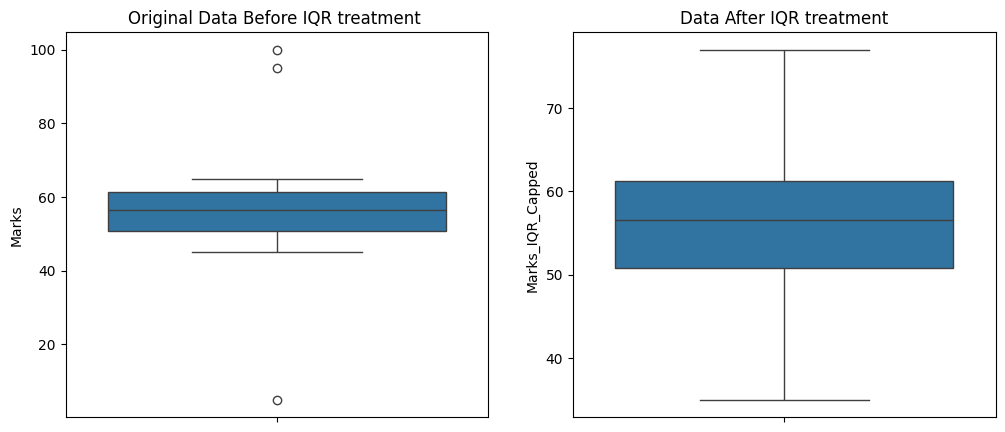

In [58]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.boxplot(y=df['Marks'],ax=axes[0])
axes[0].set_title("Original Data Before IQR treatment ")
sns.boxplot(y=df['Marks_IQR_Capped'],ax=axes[1])
axes[1].set_title("Data After IQR treatment")
plt.show()


In [59]:
print("Detecting outliers using Z-Score")
df['Z_Score']=stats.zscore(df['Marks'])
print(df[['Marks','Z_Score']])


Detecting outliers using Z-Score
    Marks   Z_Score
0      45 -0.676200
1      50 -0.400200
2      52 -0.289800
3      48 -0.510600
4      55 -0.124200
5      60  0.151800
6      58  0.041400
7      62  0.262200
8      65  0.427800
9      59  0.096600
10     61  0.207000
11     57 -0.013800
12     63  0.317400
13     56 -0.069000
14     54 -0.179400
15     51 -0.345000
16     49 -0.455400
17     95  2.083800
18    100  2.359799
19      5 -2.884199


In [67]:
print("Identifying Z- score outliers")
z_outliers=df[abs(df['Z_Score'])>3]
print("Outliers detected using Z-score")

print(z_outliers)
df['z_outlier']=abs(df['Z_Score'])>3
print(df[['Marks','Z_Score','z_outlier']])

Identifying Z- score outliers
Outliers detected using Z-score
Empty DataFrame
Columns: [Name, Marks, Marks_IQR, Marks_IQR_Capped, Z_Score, z_outlier]
Index: []
    Marks   Z_Score  z_outlier
0      45 -0.676200      False
1      50 -0.400200      False
2      52 -0.289800      False
3      48 -0.510600      False
4      55 -0.124200      False
5      60  0.151800      False
6      58  0.041400      False
7      62  0.262200      False
8      65  0.427800      False
9      59  0.096600      False
10     61  0.207000      False
11     57 -0.013800      False
12     63  0.317400      False
13     56 -0.069000      False
14     54 -0.179400      False
15     51 -0.345000      False
16     49 -0.455400      False
17     95  2.083800      False
18    100  2.359799      False
19      5 -2.884199      False


In [68]:
print("Z-score outlier Treatment - Capping")
mean=df['Marks'].mean()
std=df['Marks'].std()
lower_z_limit=mean-3*std
upper_z_limit=mean+3*std
print("Lower Z-score limit=",lower_z_limit)
print("Upper Z-score limit=",upper_z_limit)
df['Marks_Z_Capped']=(df['Marks']-mean)/std
df['Marks_Z_Capped']=df['Marks'].clip(lower=lower_z_limit,upper=upper_z_limit)
print(df[['Marks','Marks_Z_Capped']])


Z-score outlier Treatment - Capping
Lower Z-score limit= 1.4902946847626737
Upper Z-score limit= 113.00970531523733
    Marks  Marks_Z_Capped
0      45              45
1      50              50
2      52              52
3      48              48
4      55              55
5      60              60
6      58              58
7      62              62
8      65              65
9      59              59
10     61              61
11     57              57
12     63              63
13     56              56
14     54              54
15     51              51
16     49              49
17     95              95
18    100             100
19      5               5


Comparing three versions:


,Marks,Marks_IQR_Capped,Marks_Z_Capped
0,45,45,45
1,50,50,50
2,52,52,52
3,48,48,48
4,55,55,55



Visualizing comparison using boxplots:


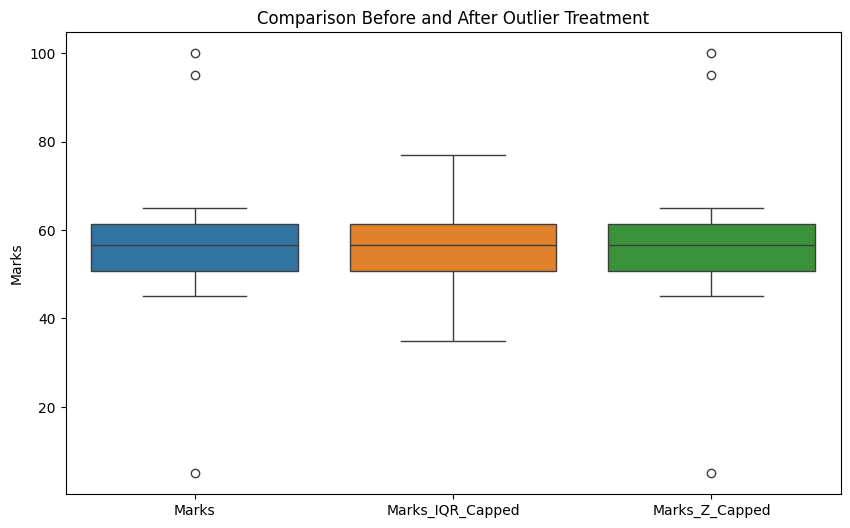

In [71]:
print("Comparing three versions:")
display(df[['Marks', 'Marks_IQR_Capped', 'Marks_Z_Capped']].head())

print("\nVisualizing comparison using boxplots:")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Marks', 'Marks_IQR_Capped', 'Marks_Z_Capped']])
plt.title("Comparison Before and After Outlier Treatment")
plt.ylabel("Marks")
plt.show()